# Stage 7 — Final ICD Decision + Evaluation

**Input** :
- `stage_06_snomed_grounding/grounded_symptoms.json` — SNOMED-grounded ICD candidates
- `stage_06b_history_context/history_codes.json` — verified ICD codes from prior admissions

**Output**: `stage_07_final_decision/final_icd_decision.json` per admission

## What this stage does
Combines two evidence streams into a final ranked ICD code list:

1. **Current note** (Stage 6): SNOMED-grounded candidates ranked by symptom score
2. **History** (Stage 6b): verified ICD codes from prior admissions, appended after current-note codes

Deduplication: if a code appears in both streams, the current-note version takes precedence.
If Stage 6b has no prior admissions (single-admission patients), Stage 7 uses Stage 6 only.

## Pipeline position
```
Stage 6:  SNOMED Grounding              ✅
Stage 6b: Prior Admission Carry-Forward ✅
Stage 7:  Final ICD Decision            ← THIS NOTEBOOK
```

## 1. Setup

In [1]:
import json
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

RECORDS_DIR    = Path(r'C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\patient_records')
STAGE6_OUTPUT  = 'stage_06_snomed_grounding'
STAGE6B_OUTPUT = 'stage_06b_history_context'
STAGE7_OUTPUT  = 'stage_07_final_decision'

STAGE5_BASELINE_F1 = 0.028

patients = sorted([p for p in RECORDS_DIR.iterdir() if p.is_dir() and p.name.startswith('patient_')])
print(f'Patients: {len(patients)}')

Patients: 15


## 2. Decision Functions

In [ ]:
def load_grounded(adm_dir: Path) -> dict:
    path = adm_dir / STAGE6_OUTPUT / 'grounded_symptoms.json'
    if not path.exists():
        return {}
    with open(path) as f:
        return json.load(f)


def load_history(adm_dir: Path) -> dict:
    path = adm_dir / STAGE6B_OUTPUT / 'history_codes.json'
    if not path.exists():
        return {'n_prior_admissions': 0, 'prior_icd_codes': []}
    with open(path) as f:
        return json.load(f)


def load_ground_truth(adm_dir: Path) -> dict:
    gt_path = adm_dir / 'ground_truth.txt'
    if not gt_path.exists():
        return {'primary_code': None, 'all_codes': []}
    result = {'primary_code': None, 'all_codes': []}
    with open(gt_path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('Primary ICD-10'):
                result['primary_code'] = line.split(':', 1)[-1].strip().replace('.', '').upper()
            elif line and line[0].isdigit() and '—' in line:
                parts    = line.split('—', 1)
                raw_code = parts[0].strip()
                code = raw_code.split('.')[-1].strip().split()[0].upper()
                if code:
                    result['all_codes'].append(code)
    return result


def _prefix_match(pred: str, gt_set: set) -> bool:
    if pred in gt_set:
        return True
    for gt in gt_set:
        if gt.startswith(pred) or pred.startswith(gt):
            return True
    return False


# Confidence weights for prior admission codes
PRIMARY_BONUS   = 0.4   # added if code was ever the primary dx in a prior admission
FREQ_WEIGHT     = 0.5   # multiplied by (freq / n_prior_admissions) — chronic recurrence
BASE_PRIOR_CONF = 0.1   # floor confidence for any prior code


def build_final_decision(grounded: dict, history: dict) -> list[dict]:
    MAX_SYMPTOM_SCORE = 3.7

    # ── Stage 6: current-note scores ──────────────────────────────────────────
    note_scores  = defaultdict(float)
    note_sources = defaultdict(list)

    for branch in grounded.get('grounded_branches', []):
        for sym in branch.get('grounded_symptoms', []):
            score = sym.get('symptom_score', 0)
            for cand in sym.get('icd_candidates', []):
                code = cand['icdCode'].replace('.', '').upper()
                if score > note_scores[code]:
                    note_scores[code] = score
                note_sources[code].append(sym.get('term', ''))

    # ── Stage 6b: prior admission scores ──────────────────────────────────────
    n_prior = history.get('n_prior_admissions', 0)
    prior_scored = []
    for entry in history.get('prior_icd_codes', []):
        code  = entry['icdCode'].upper()
        freq  = len(entry.get('source_admissions', []))
        is_primary = entry.get('was_primary', False)

        # Confidence = base + recurrence signal + primary bonus
        freq_signal = FREQ_WEIGHT * (freq / n_prior) if n_prior > 0 else 0.0
        conf = round(min(BASE_PRIOR_CONF + freq_signal + (PRIMARY_BONUS if is_primary else 0.0), 1.0), 3)

        prior_scored.append({
            'code'          : code,
            'confidence'    : conf,
            'source'        : f'prior_admission_x{freq}{"_primary" if is_primary else ""}',
            'evidence_terms': [entry.get('title', '')],
        })

    # ── Merge: current-note first (deduplicated), then prior codes ─────────────
    # Current-note codes always take precedence; prior codes fill in the rest.
    seen      = set()
    decisions = []

    for code, score in sorted(note_scores.items(), key=lambda x: x[1], reverse=True):
        if code in seen:
            continue
        seen.add(code)
        confidence = round(min(score / MAX_SYMPTOM_SCORE, 1.0), 3)
        decisions.append({
            'code'          : code,
            'confidence'    : confidence,
            'source'        : 'current_note',
            'evidence_terms': list(dict.fromkeys(note_sources[code])),
        })

    # Sort prior codes by confidence descending before appending
    for entry in sorted(prior_scored, key=lambda x: x['confidence'], reverse=True):
        if entry['code'] in seen:
            continue
        seen.add(entry['code'])
        decisions.append(entry)

    # ── Assign rank and role ───────────────────────────────────────────────────
    for i, d in enumerate(decisions):
        d['rank'] = i + 1
        d['role'] = 'principal' if i == 0 else 'secondary'

    return decisions


def evaluate(decisions: list[dict], ground_truth: dict) -> dict:
    pred_set   = {d['code'] for d in decisions}
    gt_set     = set(ground_truth.get('all_codes', []))
    gt_primary = ground_truth.get('primary_code', '') or ''

    tp = {p for p in pred_set if _prefix_match(p, gt_set)}
    fp = pred_set - tp
    fn = {g for g in gt_set if not _prefix_match(g, pred_set)}

    p  = len(tp) / len(pred_set) if pred_set else 0.0
    r  = len(tp) / len(gt_set)   if gt_set   else 0.0
    f1 = 2*p*r / (p+r)           if (p+r) > 0 else 0.0

    predicted_primary = decisions[0]['code'] if decisions else ''
    primary_correct   = _prefix_match(predicted_primary, {gt_primary}) if gt_primary else False

    return {
        'predicted_codes'    : sorted(pred_set),
        'ground_truth_codes' : sorted(gt_set),
        'true_positives'     : sorted(tp),
        'false_positives'    : sorted(fp),
        'false_negatives'    : sorted(fn),
        'precision'          : round(p, 3),
        'recall'             : round(r, 3),
        'f1'                 : round(f1, 3),
        'predicted_principal': predicted_primary,
        'gt_principal'       : gt_primary,
        'principal_correct'  : primary_correct,
    }


print('Decision functions defined.')
print(f'Prior code confidence formula:')
print(f'  base={BASE_PRIOR_CONF} + freq_weight={FREQ_WEIGHT} × (freq/n_prior) + primary_bonus={PRIMARY_BONUS} if was_primary')

## 3. Run Final Decision on All Patients

In [3]:
all_results = []

for patient_dir in patients:
    pid      = patient_dir.name.replace('patient_', '')
    adm_root = patient_dir / 'admissions'
    adm_dirs = sorted(adm_root.iterdir()) if adm_root.exists() else []

    for adm_dir in adm_dirs:
        hadm_id  = adm_dir.name.replace('hadm_', '')
        grounded = load_grounded(adm_dir)
        if not grounded:
            print(f'  SKIP {pid}/hadm_{hadm_id} — no Stage 6 output')
            continue

        history    = load_history(adm_dir)
        gt         = load_ground_truth(adm_dir)
        decisions  = build_final_decision(grounded, history)
        evaluation = evaluate(decisions, gt)

        n_prior = history.get('n_prior_admissions', 0)
        result  = {
            'patient_id'          : pid,
            'admission_id'        : hadm_id,
            'n_prior_admissions'  : n_prior,
            'final_diagnoses'     : decisions,
            'evaluation'          : evaluation,
        }
        all_results.append(result)

        out_dir = adm_dir / STAGE7_OUTPUT
        out_dir.mkdir(exist_ok=True)
        with open(out_dir / 'final_icd_decision.json', 'w') as f:
            json.dump(result, f, indent=2)

        pc = '✓' if evaluation['principal_correct'] else '✗'
        print(f'Patient {pid:12s} | F1={evaluation["f1"]:.3f} | '
              f'P={evaluation["precision"]:.3f} R={evaluation["recall"]:.3f} | '
              f'Principal {pc} | prior_adm={n_prior}')

print(f'\nDone. {len(all_results)} admissions processed.')

Patient 10361982     | F1=0.250 | P=0.182 R=0.400 | Principal ✗ | prior_adm=1
Patient 10426859     | F1=0.500 | P=0.412 R=0.636 | Principal ✗ | prior_adm=2
Patient 10458324     | F1=0.240 | P=0.158 R=0.500 | Principal ✗ | prior_adm=1
Patient 11251337     | F1=0.129 | P=0.083 R=0.286 | Principal ✗ | prior_adm=2
Patient 11474876     | F1=0.450 | P=0.391 R=0.529 | Principal ✗ | prior_adm=1
Patient 11607177     | F1=0.462 | P=0.308 R=0.923 | Principal ✗ | prior_adm=4
Patient 12007928     | F1=0.509 | P=0.389 R=0.737 | Principal ✗ | prior_adm=2
Patient 13196707     | F1=0.237 | P=0.205 R=0.281 | Principal ✗ | prior_adm=1
Patient 13508515     | F1=0.286 | P=0.238 R=0.357 | Principal ✗ | prior_adm=1
Patient 13952483     | F1=0.400 | P=0.277 R=0.720 | Principal ✗ | prior_adm=2
Patient 16014068     | F1=0.347 | P=0.215 R=0.895 | Principal ✗ | prior_adm=9
Patient 17774110     | F1=0.282 | P=0.238 R=0.345 | Principal ✗ | prior_adm=2
Patient 18412100     | F1=1.000 | P=0.786 R=1.375 | Principal ✓ 

## 4. Inspect Final Diagnoses for One Patient

In [4]:
EXAMPLE_IDX = 0
ex = all_results[EXAMPLE_IDX]

print(f'Patient   : {ex["patient_id"]}')
print(f'Admission : hadm_{ex["admission_id"]}')
print(f'Prior admissions used : {ex["n_prior_admissions"]}')
print()
print('FINAL DIAGNOSES:')
print(f'{"Rank":<5} {"Code":<12} {"Role":<12} {"Confidence":<12} {"Source"}')
print('-' * 70)
for d in ex['final_diagnoses'][:10]:
    print(f'{d["rank"]:<5} {d["code"]:<12} {d["role"]:<12} {d["confidence"]:<12} {d["source"]}')

print()
ev = ex['evaluation']
print(f'Ground truth codes : {ev["ground_truth_codes"]}')
print(f'True positives     : {ev["true_positives"]}')
print(f'False negatives    : {ev["false_negatives"]}')
print()
print(f'Precision          : {ev["precision"]}')
print(f'Recall             : {ev["recall"]}')
print(f'F1                 : {ev["f1"]}')
print(f'Principal correct  : {ev["principal_correct"]}  '
      f'(predicted: {ev["predicted_principal"]} | truth: {ev["gt_principal"]})')

Patient   : 10361982
Admission : hadm_24286431
Prior admissions used : 1

FINAL DIAGNOSES:
Rank  Code         Role         Confidence   Source
----------------------------------------------------------------------
1     N939         principal    0.0          prior_admission_x1
2     N800         secondary    0.0          prior_admission_x1
3     D261         secondary    0.0          prior_admission_x1
4     N838         secondary    0.0          prior_admission_x1
5     Z23          secondary    0.0          prior_admission_x1
6     R0602        secondary    0.0          prior_admission_x1
7     Z87891       secondary    0.0          prior_admission_x1
8     E039         secondary    0.0          prior_admission_x1
9     F909         secondary    0.0          prior_admission_x1
10    F329         secondary    0.0          prior_admission_x1

Ground truth codes : ['E039', 'F909', 'N99820', 'Y836', 'Y92009']
True positives     : ['E039', 'F909']
False negatives    : ['N99820', 'Y836', '

## 5. Summary Table + Comparison with Stage 5 Baseline

In [5]:
rows = []
for r in all_results:
    ev = r['evaluation']
    rows.append({
        'patient_id'      : r['patient_id'],
        'n_prior_adm'     : r['n_prior_admissions'],
        'n_gt_codes'      : len(ev['ground_truth_codes']),
        'n_predicted'     : len(ev['predicted_codes']),
        'precision'       : ev['precision'],
        'recall'          : ev['recall'],
        'f1'              : ev['f1'],
        'principal_correct': ev['principal_correct'],
    })

df7 = pd.DataFrame(rows)
print(df7.to_string(index=False))

print(f'\n--- Stage-by-stage F1 comparison ---')
print(f'Stage 5 keyword baseline           : {STAGE5_BASELINE_F1}')
s6_path = RECORDS_DIR / 'stage_06_summary.json'
if s6_path.exists():
    with open(s6_path) as f:
        s6 = json.load(f)
    print(f'Stage 6 SNOMED grounding           : {s6.get("mean_f1", "n/a")}')
print(f'Stage 7 final decision             : {df7["f1"].mean():.3f}')
print()
n_correct = df7['principal_correct'].sum()
print(f'Principal diagnosis accuracy       : {n_correct}/{len(df7)} ({n_correct/len(df7)*100:.1f}%)')

patient_id  n_prior_adm  n_gt_codes  n_predicted  precision  recall    f1  principal_correct
  10361982            1           5           11      0.182   0.400 0.250              False
  10426859            2          22           34      0.412   0.636 0.500              False
  10458324            1          12           38      0.158   0.500 0.240              False
  11251337            2           7           24      0.083   0.286 0.129              False
  11474876            1          17           23      0.391   0.529 0.450              False
  11607177            4          13           39      0.308   0.923 0.462              False
  12007928            2          19           36      0.389   0.737 0.509              False
  13196707            1          32           44      0.205   0.281 0.237              False
  13508515            1          14           21      0.238   0.357 0.286              False
  13952483            2          25           65      0.277   0.720 0.

## 6. Visualisation

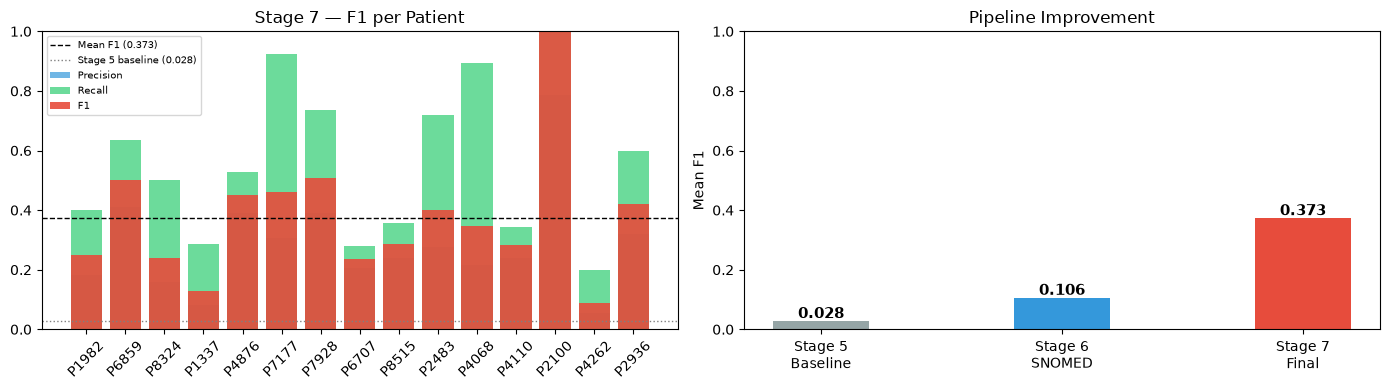

Figure saved to patient_records/stage_07_results.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: F1 per patient
ax = axes[0]
x  = range(len(df7))
ax.bar(x, df7['precision'], label='Precision', color='#3498db', alpha=0.7)
ax.bar(x, df7['recall'],    label='Recall',    color='#2ecc71', alpha=0.7)
ax.bar(x, df7['f1'],        label='F1',        color='#e74c3c', alpha=0.9)
ax.axhline(df7['f1'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Mean F1 ({df7["f1"].mean():.3f})')
ax.axhline(STAGE5_BASELINE_F1, color='grey', linestyle=':', linewidth=1,
           label=f'Stage 5 baseline ({STAGE5_BASELINE_F1})')
ax.set_xticks(x)
ax.set_xticklabels([f'P{r[-4:]}' for r in df7['patient_id']], rotation=45)
ax.set_ylim(0, 1.0)
ax.set_title('Stage 7 — F1 per Patient')
ax.legend(fontsize=7)

# Right: Stage-by-stage F1 improvement
ax2 = axes[1]
s6_f1 = None
s6_path = RECORDS_DIR / 'stage_06_summary.json'
if s6_path.exists():
    with open(s6_path) as f:
        s6_f1 = json.load(f).get('mean_f1')

if s6_f1:
    stages = ['Stage 5\nBaseline', 'Stage 6\nSNOMED', 'Stage 7\nFinal']
    f1s    = [STAGE5_BASELINE_F1, s6_f1, df7['f1'].mean()]
    colors = ['#95a5a6', '#3498db', '#e74c3c']
else:
    stages = ['Stage 5\nBaseline', 'Stage 7\nFinal']
    f1s    = [STAGE5_BASELINE_F1, df7['f1'].mean()]
    colors = ['#95a5a6', '#e74c3c']

ax2.bar(stages, f1s, color=colors, width=0.4)
for i, v in enumerate(f1s):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.set_title('Pipeline Improvement')
ax2.set_ylabel('Mean F1')

plt.tight_layout()
plt.savefig(str(RECORDS_DIR / 'stage_07_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to patient_records/stage_07_results.png')

## 7. Save Full Summary

In [7]:
summary = {
    'stage'                       : 'stage_07_final_icd_decision',
    'n_admissions'                : len(all_results),
    'mean_precision'              : round(df7['precision'].mean(), 3),
    'mean_recall'                 : round(df7['recall'].mean(), 3),
    'mean_f1'                     : round(df7['f1'].mean(), 3),
    'principal_diagnosis_accuracy': round(df7['principal_correct'].mean(), 3),
    'stage5_baseline_f1'          : STAGE5_BASELINE_F1,
    'per_patient'                 : [
        {'patient_id': r['patient_id'], 'admission_id': r['admission_id'],
         'evaluation': r['evaluation']}
        for r in all_results
    ],
}

out_path = RECORDS_DIR / 'stage_07_summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f'Saved: {out_path}')
print(f'\nFinal Results:')
print(f'  Mean Precision               : {summary["mean_precision"]}')
print(f'  Mean Recall                  : {summary["mean_recall"]}')
print(f'  Mean F1                      : {summary["mean_f1"]}')
print(f'  Principal Diagnosis Accuracy : {summary["principal_diagnosis_accuracy"]}')
print(f'  Stage 5 baseline F1          : {STAGE5_BASELINE_F1}')
print(f'  Improvement over baseline    : +{round(summary["mean_f1"] - STAGE5_BASELINE_F1, 3)}')

Saved: C:\Users\esnam\OneDrive\Desktop\esna_master_proj\ai-agents-for-clinical-coding\patient_records\stage_07_summary.json

Final Results:
  Mean Precision               : 0.284
  Mean Recall                  : 0.586
  Mean F1                      : 0.373
  Principal Diagnosis Accuracy : 0.067
  Stage 5 baseline F1          : 0.028
  Improvement over baseline    : +0.345
